In [1]:
from src.model import PyTradeShifts
from src.postprocessing import Postprocessing
import pandas as pd
import os
os.chdir('../../')
print(os.getcwd())

/home/florian/Documents/GitHub/pytradeshifts


# AMOC Collapse — Trade After Catastrophe

This notebook analyses the impact of an AMOC (Atlantic Meridional Overturning Circulation) collapse on global agricultural trade for **Wheat**, **Maize**, and **Rice** using base year **2023**.

The yield reduction data comes from `data/scenario_files/AMOC Collapse/country_total_calories_decline.csv`, which contains per-crop percentage changes in production for each country.

The analyses shown here are:
- **Relative import difference** between the base scenario and the AMOC collapse scenario
- **Trade communities** in both the base and AMOC collapse scenario
- **Trade community change** (how communities reorganise under AMOC collapse)
- **Jaccard distance** (how much each country's trade community membership changes)

## Prepare per-crop scenario files

The AMOC CSV contains yield changes for all crops in a single file. `PyTradeShifts` expects one file per crop with the country as index and a single value column. We extract the relevant columns here and write them to the `AMOC Collapse` scenario folder.

In [2]:
import country_converter as coco

amoc_raw = pd.read_csv(
    "data/scenario_files/AMOC Collapse/country_total_calories_decline.csv",
    index_col=0,
)

cc = coco.CountryConverter()

# Crop column mapping: model crop name -> column in the AMOC CSV
crop_columns = {
    "Wheat": "wheat_total_change_pct",
    "Maize": "maize_total_change_pct",
    "Rice":  "rice_total_change_pct",
}

for crop, col in crop_columns.items():
    crop_data = amoc_raw[[col]].dropna().copy()
    # Pre-check which country names convert cleanly (apply_scenario does the same conversion).
    # Entries that resolve to "not found" or create duplicates would cause a reindex error.
    converted = cc.pandas_convert(pd.Series(crop_data.index), to="name_short")
    valid = (converted != "not found") & (~converted.duplicated(keep="first"))
    dropped = crop_data.index[~valid.values].tolist()
    if dropped:
        print(f"{crop}: dropping unresolvable/duplicate countries: {dropped}")
    crop_data = crop_data[valid.values]
    out_path = f"data/scenario_files/AMOC Collapse/{crop.lower()}_amoc_collapse.csv"
    crop_data.to_csv(out_path)
    print(f"{crop}: {len(crop_data)} countries affected, median yield change = {crop_data[col].median():.2f}%")

Wheat: dropping unresolvable/duplicate countries: ['S. Sudan']
Wheat: 130 countries affected, median yield change = -2.68%
Maize: dropping unresolvable/duplicate countries: ['S. Sudan', 'Somalia']
Maize: 153 countries affected, median yield change = -0.80%
Rice: dropping unresolvable/duplicate countries: ['S. Sudan']
Rice: 116 countries affected, median yield change = -0.70%


---
## Load FAO Food Balance Sheet consumption data

Domestic food consumption figures come from the FAO Food Balance Sheets (FBS).
The ZIP is converted to a pickle once and reused on subsequent runs.

In [3]:
import os
from src.preprocessing import serialise_faostat_bulk, prep_fbs_consumption

base_year = 2023

fbs_zip = "data/data_raw/FoodBalanceSheets_E_All_Data.zip"
fbs_pkl = "data/temp_files/FoodBalanceSheets_E_All_Data.pkl"

if not os.path.exists(fbs_pkl):
    serialise_faostat_bulk(fbs_zip)

fbs_year = f"Y{base_year}"

wheat_consumption = prep_fbs_consumption(fbs_pkl, item="Wheat and products", year=fbs_year)
# Maize is primarily used for animal feed in most countries, not human food.
# Using "Domestic supply quantity" (food + feed + processing) gives a meaningful
# denominator; "Food" alone is tiny for countries like Spain and produces
# spuriously large percentages.
maize_consumption = prep_fbs_consumption(fbs_pkl, item="Maize and products", year=fbs_year, element="Domestic supply quantity")
rice_consumption  = prep_fbs_consumption(fbs_pkl, item="Rice and products",  year=fbs_year)

print(f"FBS consumption loaded for {fbs_year}.")
print(f"  Wheat: {len(wheat_consumption)} countries")
print(f"  Maize: {len(maize_consumption)} countries")
print(f"  Rice:  {len(rice_consumption)} countries")

FBS consumption loaded for Y2023.
  Wheat: 180 countries
  Maize: 180 countries
  Rice:  180 countries


---
## Wheat

In [4]:
base_year = 2023

wheat_base = PyTradeShifts(
    "Wheat",
    base_year=base_year,
    region="Global",
    testing=False,
    cd_kwargs={"seed": 2},
    make_plot=False,
)
wheat_amoc = PyTradeShifts(
    crop="Wheat",
    base_year=base_year,
    scenario_file_name="AMOC Collapse/wheat_amoc_collapse.csv",
    scenario_name="AMOC Collapse",
    cd_kwargs={"seed": 2},
    make_plot=False,
)

wheat_comparison = Postprocessing(
    [wheat_base, wheat_amoc],
    anchor_countries=["United States", "Russia", "Australia", "Germany"],
    consumption_data=wheat_consumption,
)

Loaded data for Wheat in Y2023.
Removed 2 countries with no trade or production.
Removed countries: ['Marshall Islands', 'Sao Tome and Principe']
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Built trade graph.
Found 7 trade communities.
Loaded data for Wheat in Y2023.
Removed 2 countries with no trade or production.
Removed countries: ['Marshall Islands', 'Sao Tome and Principe']
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Applied scenario AMOC Collapse.
Built trade graph.
Found 7 trade communities.
Starting postprocessing computations...


### Relative import difference (Wheat)

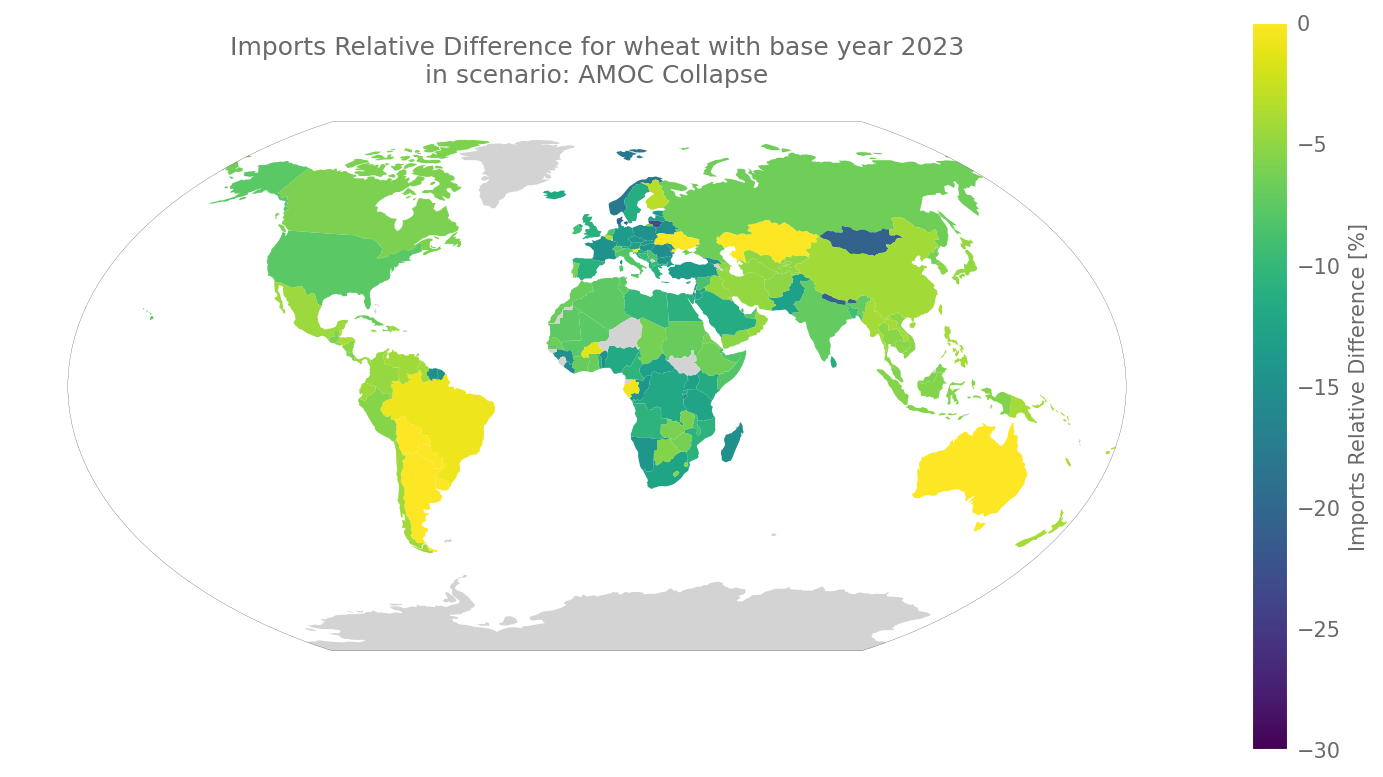

In [ ]:
wheat_comparison.plot_imports_difference(figsize=(10, 10), vmin=-30, vmax=0, shrink=0.5)

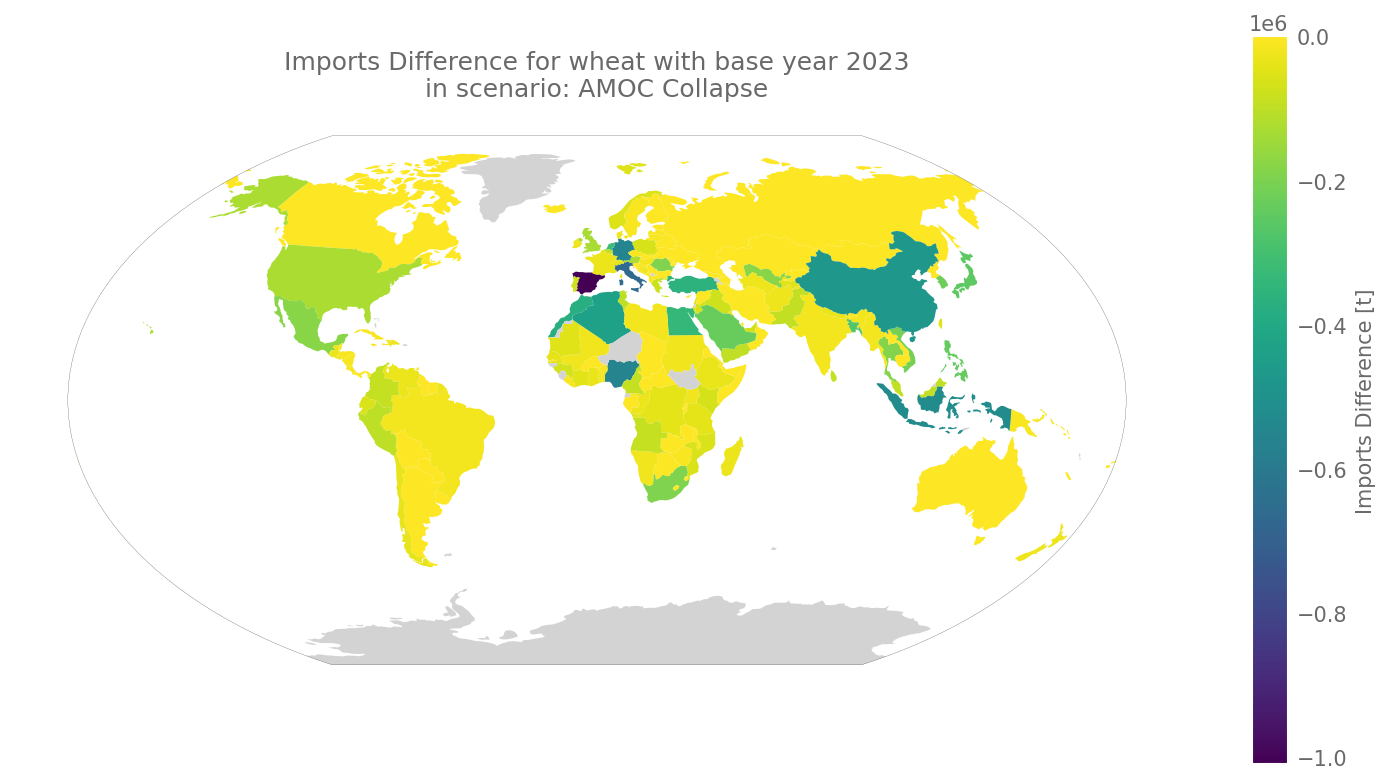

In [6]:
wheat_comparison.plot_imports_difference_absolute(figsize=(10, 10), shrink=0.5)

### Import change as fraction of consumption (Wheat)

How large is the scenario-induced import change relative to each country's domestic
food consumption of wheat? A value of −5 % means a country's imports fell by an amount
equivalent to 5 % of its normal wheat consumption.

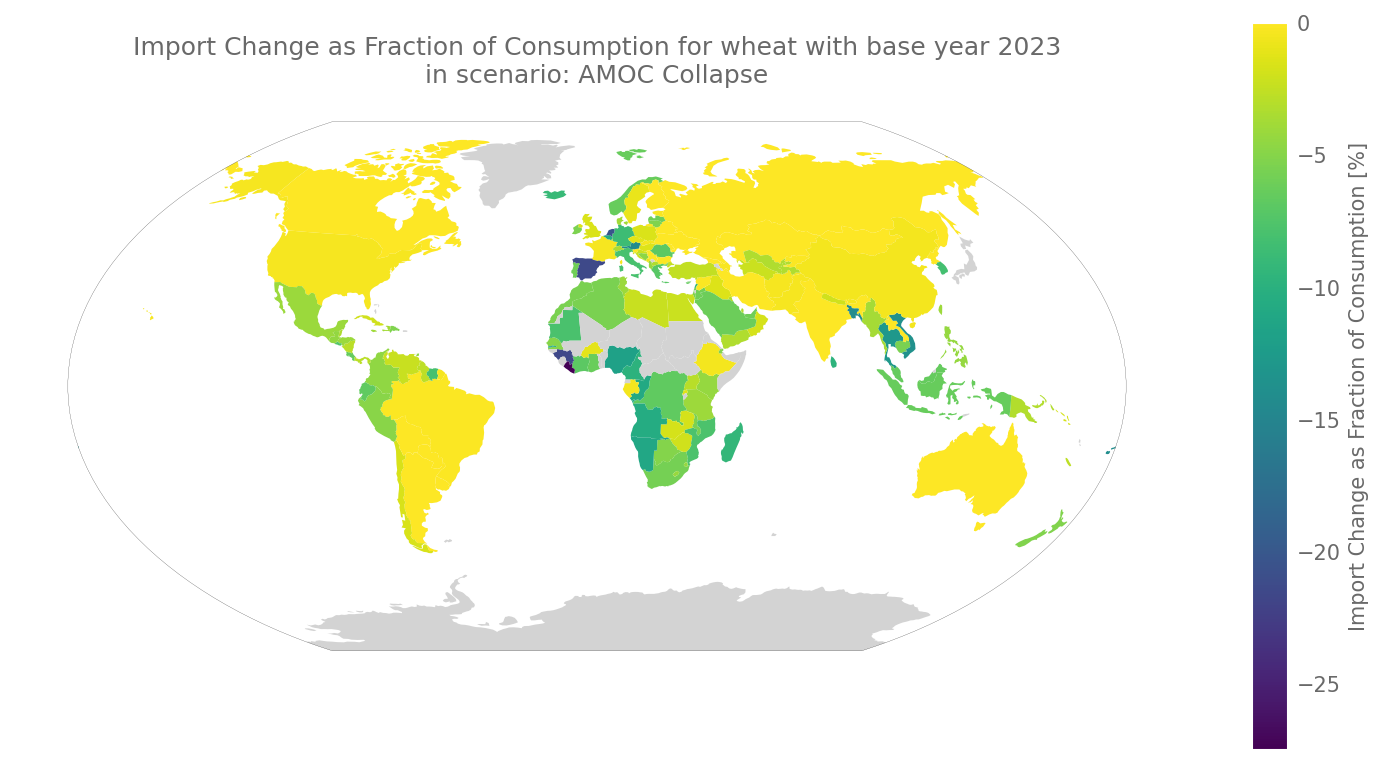

In [22]:
wheat_comparison.plot_import_change_as_fraction_of_consumption(figsize=(10, 10), vmax=0, vmin=-27.5, shrink=0.5)

### Trade communities (Wheat)

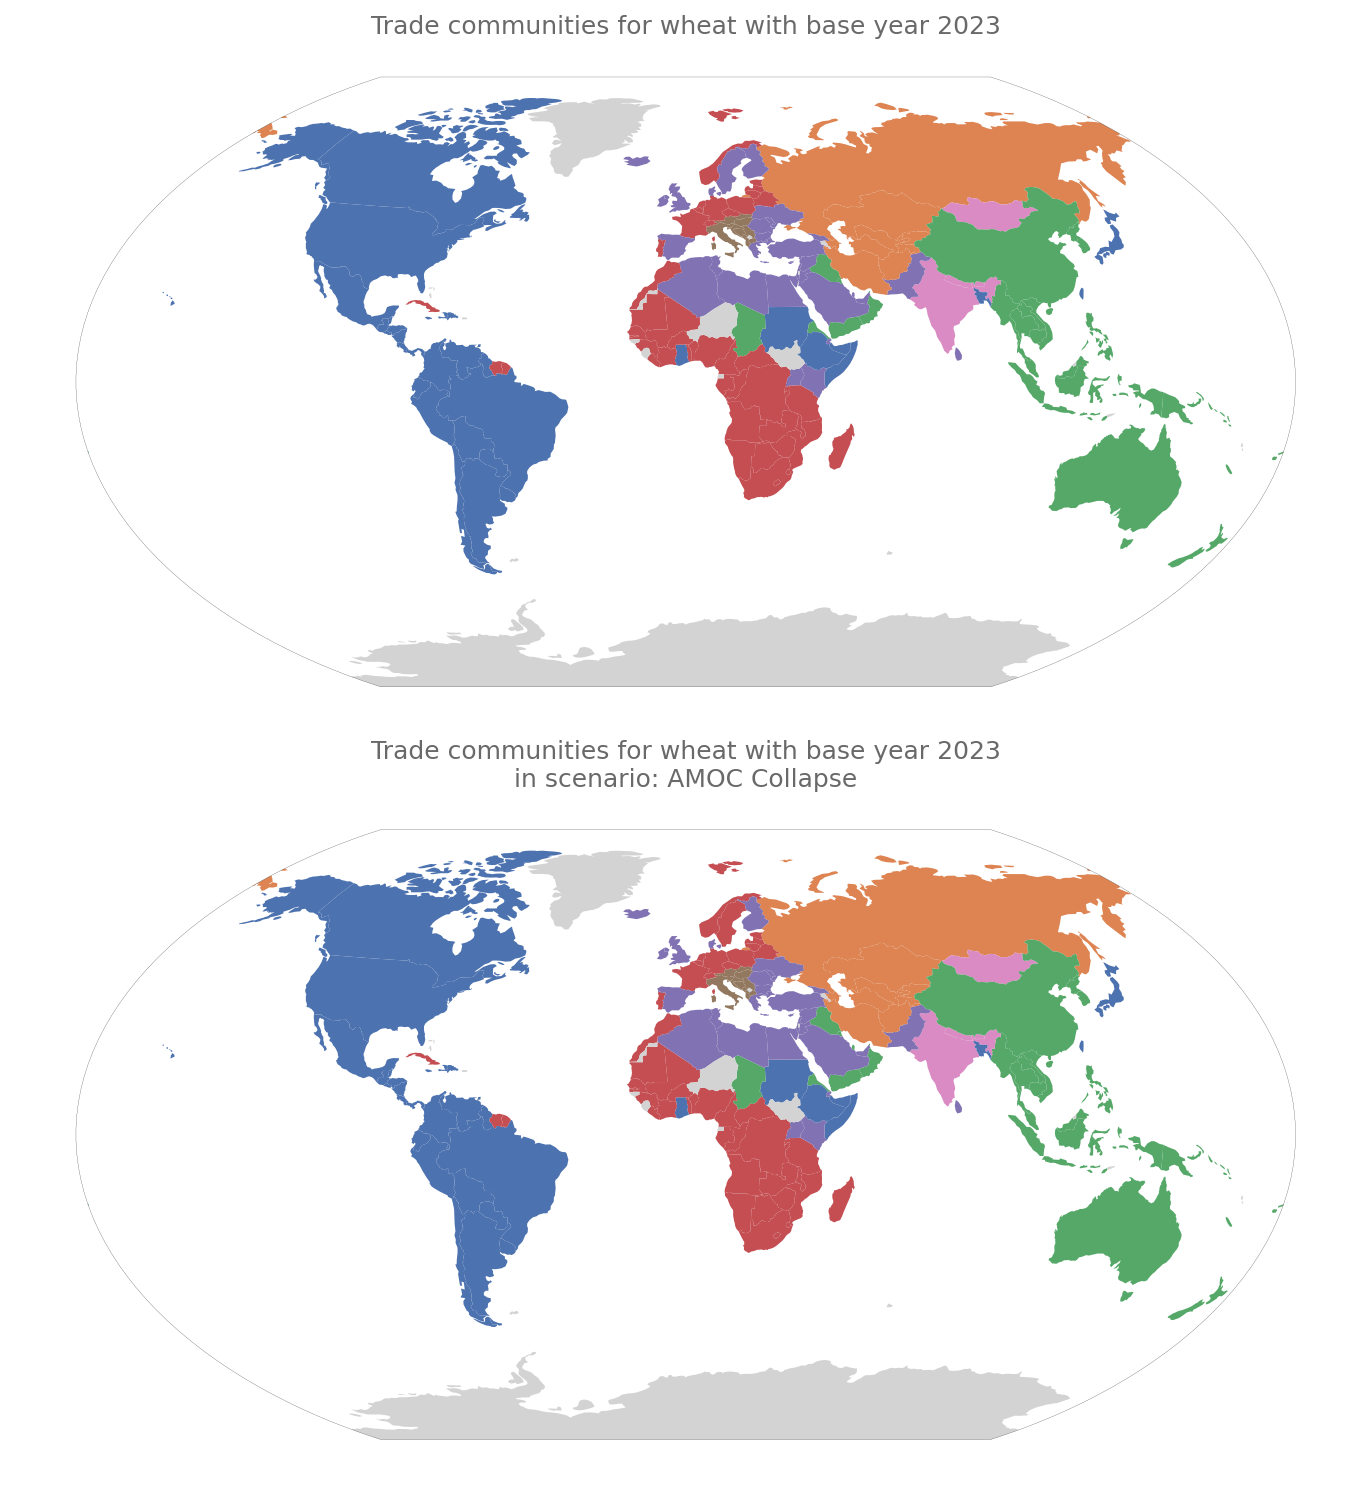

In [8]:
wheat_comparison.plot_all_trade_communities(figsize=(15, 10))

### Trade community change — Jaccard distance (Wheat)

The Jaccard distance (1 − Jaccard index) quantifies how much each country's trade community membership changed between the base scenario and the AMOC collapse scenario. A value of 0 means no change; a value of 1 means the country moved to a completely different community.

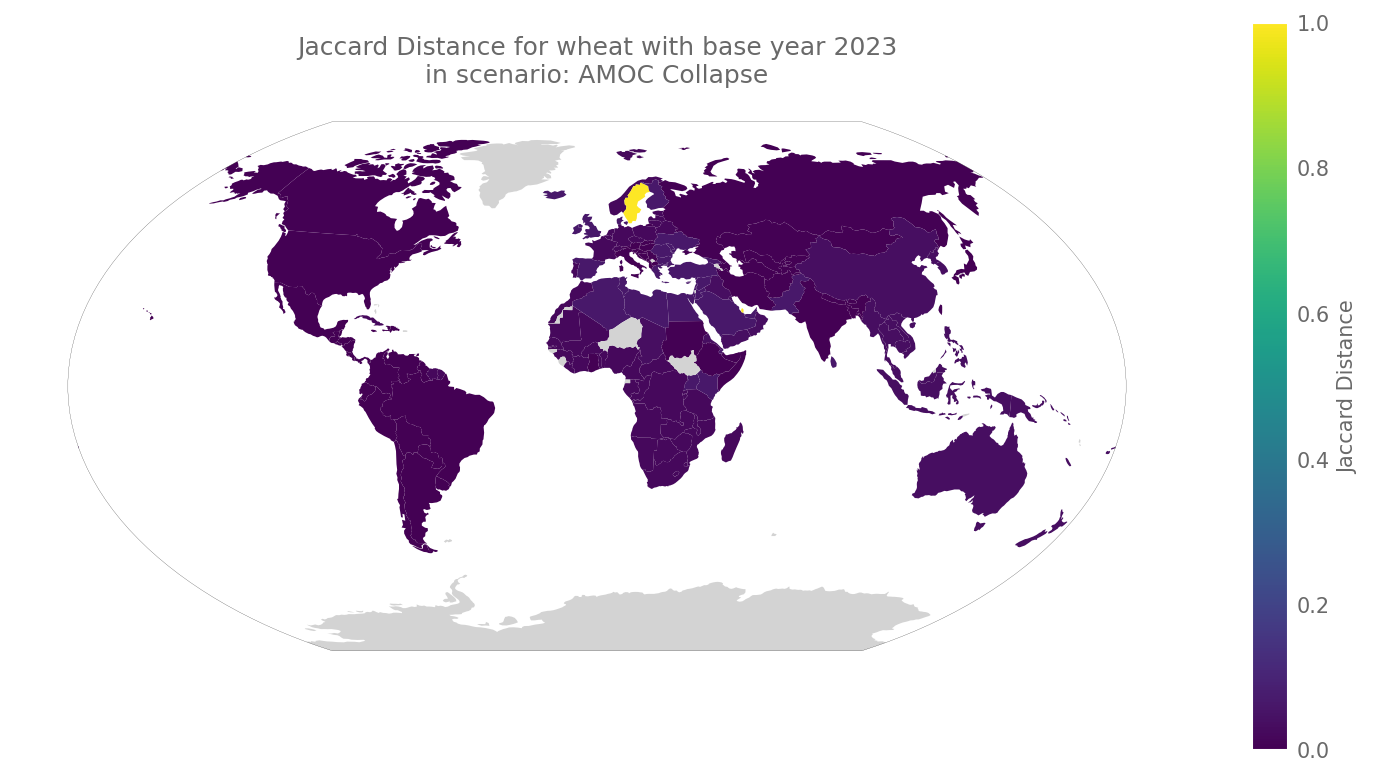

In [9]:
wheat_comparison.plot_community_difference(figsize=(10, 10), vmin=0, vmax=1, shrink=0.5)

---
## Maize

In [10]:
maize_base = PyTradeShifts(
    "Maize",
    base_year=base_year,
    region="Global",
    testing=False,
    cd_kwargs={"seed": 2},
    make_plot=False,
)
maize_amoc = PyTradeShifts(
    crop="Maize",
    base_year=base_year,
    scenario_file_name="AMOC Collapse/maize_amoc_collapse.csv",
    scenario_name="AMOC Collapse",
    cd_kwargs={"seed": 2},
    make_plot=False,
)

maize_comparison = Postprocessing(
    [maize_base, maize_amoc],
    anchor_countries=["United States", "India", "South Africa"],
    consumption_data=maize_consumption,
)

The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Maize in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Built trade graph.
Found 7 trade communities.
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Maize in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Applied scenario AMOC Collapse.
Built trade graph.
Found 7 trade communities.
Starting postprocessing co

### Relative import difference (Maize)

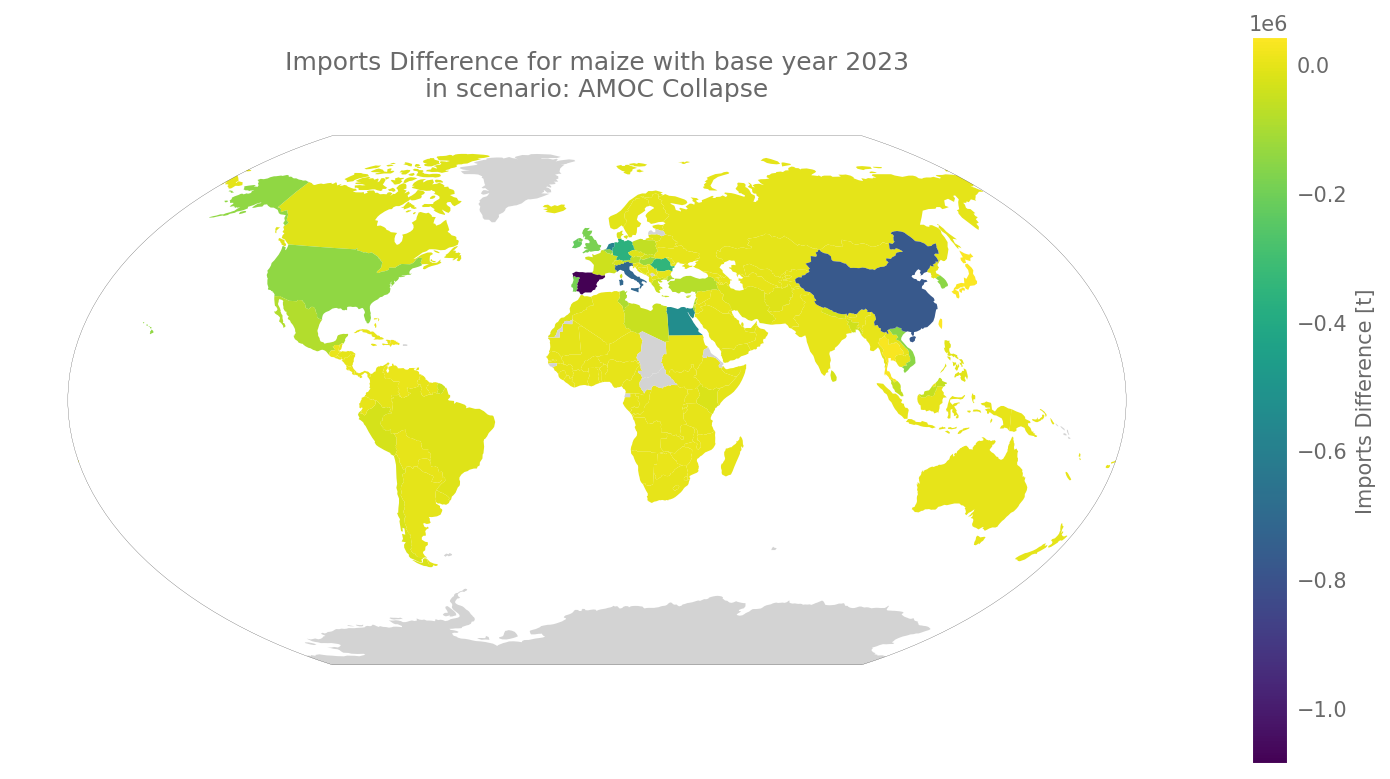

In [11]:
maize_comparison.plot_imports_difference_absolute(figsize=(10, 10), shrink=0.5)

### Import change as fraction of domestic supply (Maize)

How large is the scenario-induced import change relative to each country's domestic
supply of maize (food + feed + processing)? A value of −5 % means a country's imports
fell by an amount equivalent to 5 % of its normal domestic maize supply.

Note: unlike wheat and rice, maize is used predominantly for animal feed and
industrial processing rather than direct human food. "Domestic supply quantity"
is therefore used as the denominator rather than "Food" to avoid artificially
inflated percentages for major feed-maize importers such as Spain.

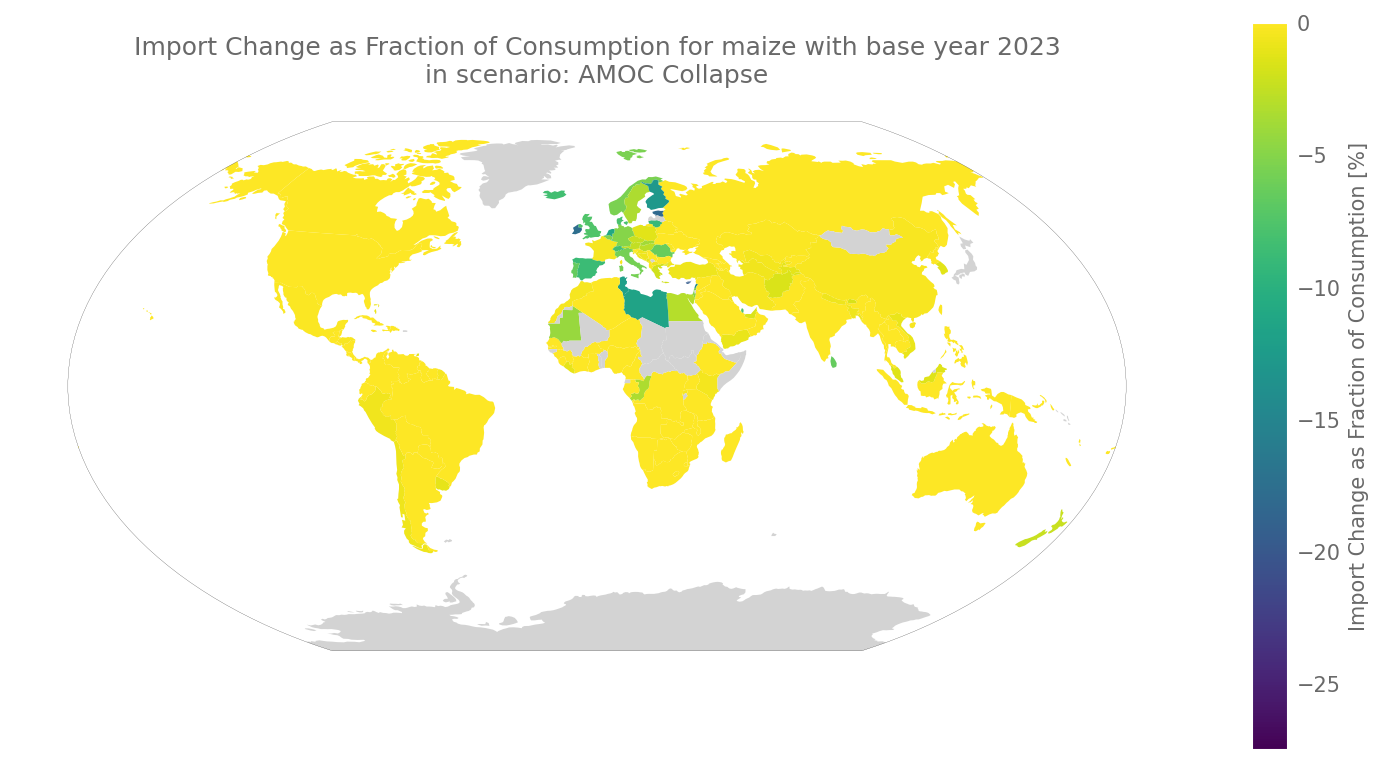

In [23]:
maize_comparison.plot_import_change_as_fraction_of_consumption(figsize=(10, 10), vmax=0, vmin=-27.5, shrink=0.5)

### Trade communities (Maize)

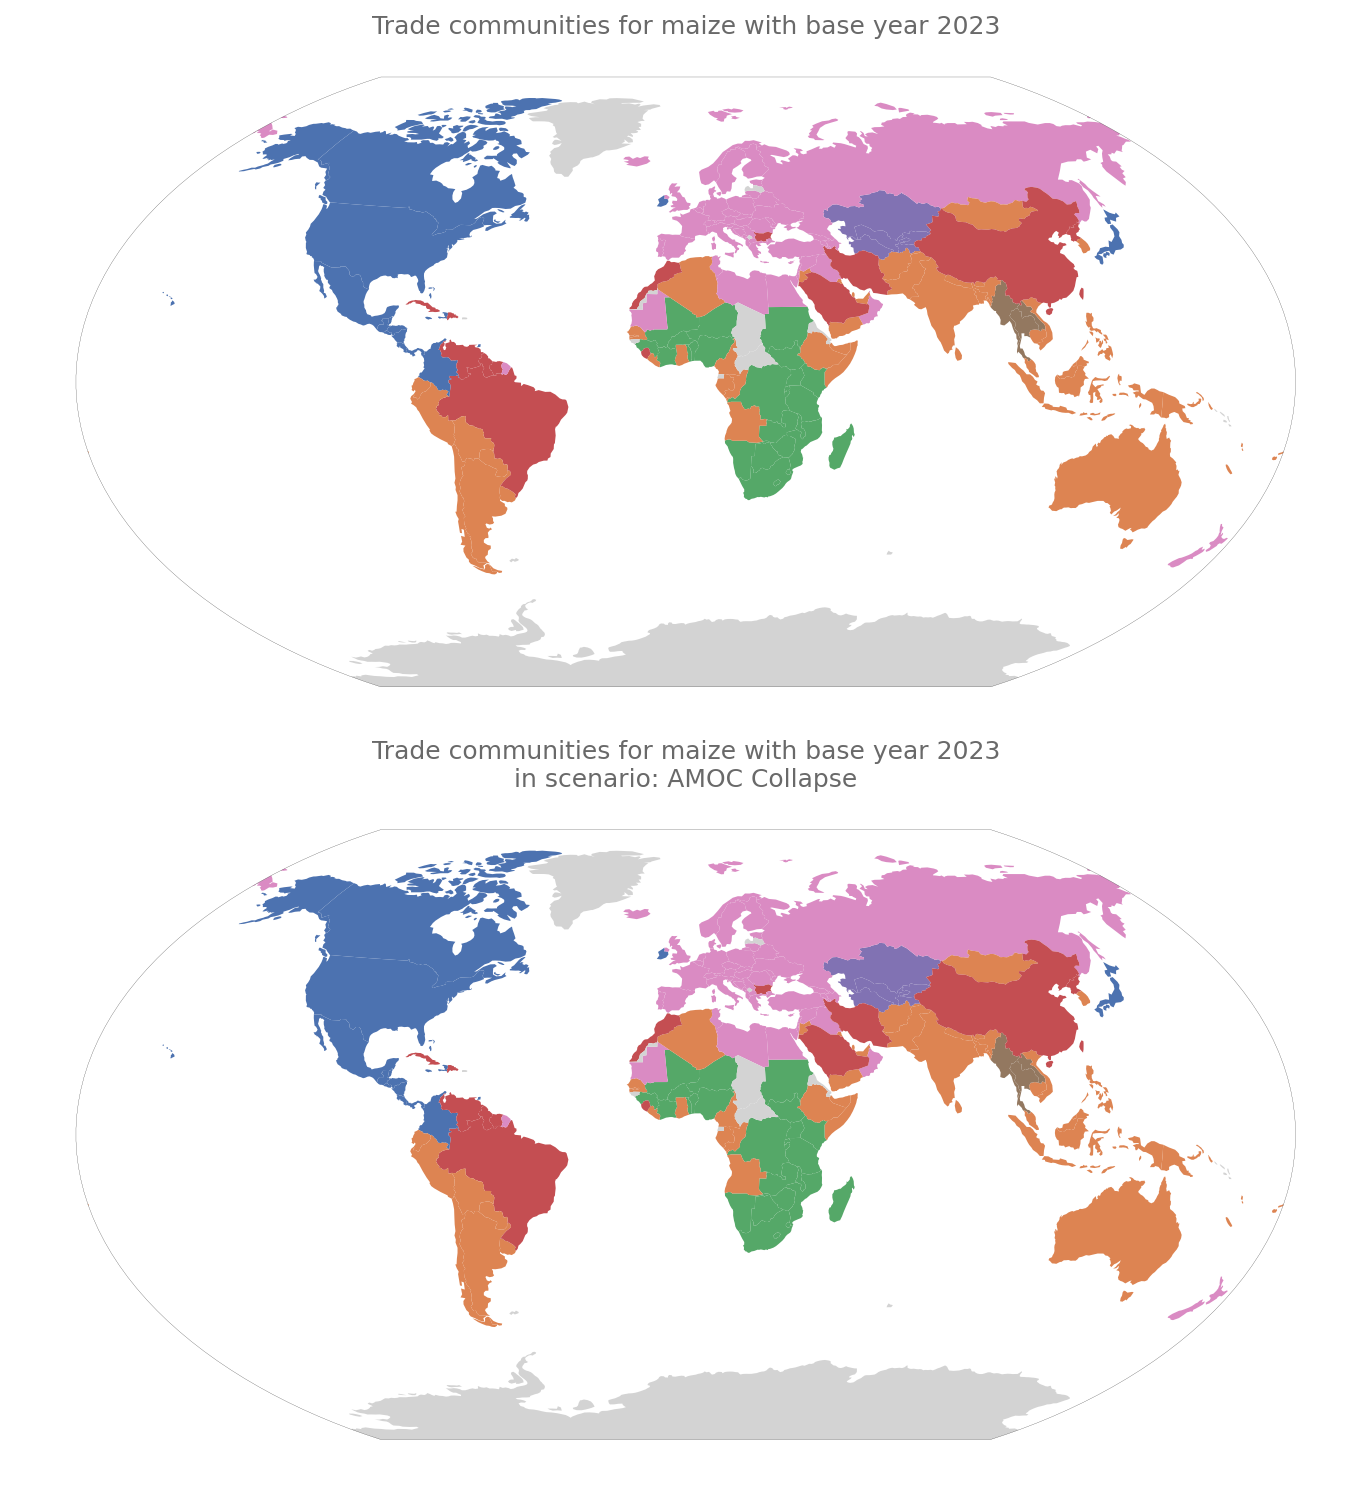

In [13]:
maize_comparison.plot_all_trade_communities(figsize=(15, 10))

### Trade community change — Jaccard distance (Maize)

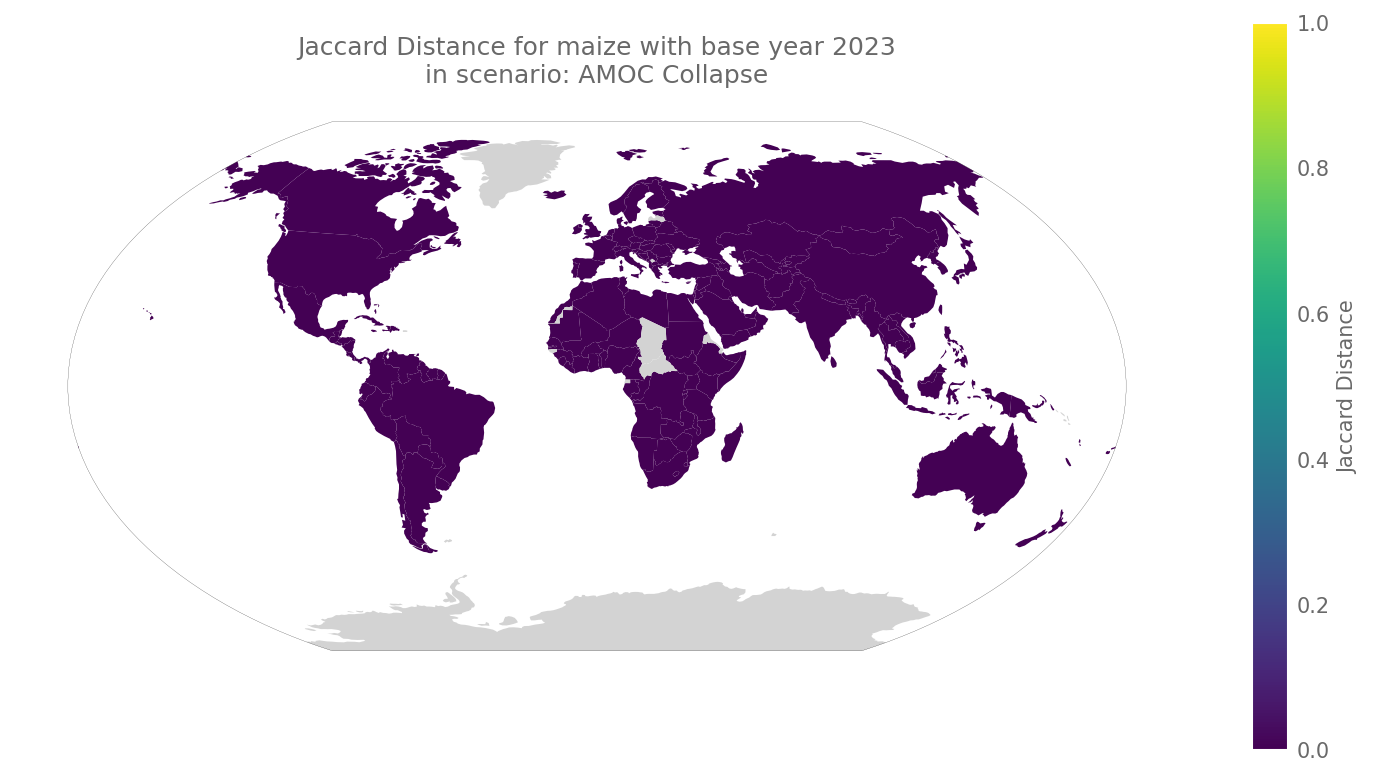

In [14]:
maize_comparison.plot_community_difference(figsize=(10, 10), vmin=0, vmax=1, shrink=0.5)

---
## Rice

In [15]:
rice_base = PyTradeShifts(
    "Rice",
    base_year=base_year,
    region="Global",
    testing=False,
    cd_kwargs={"seed": 2},
    make_plot=False,
)
rice_amoc = PyTradeShifts(
    crop="Rice",
    base_year=base_year,
    scenario_file_name="AMOC Collapse/rice_amoc_collapse.csv",
    scenario_name="AMOC Collapse",
    cd_kwargs={"seed": 2},
    make_plot=False,
)

rice_comparison = Postprocessing(
    [rice_base, rice_amoc],
    anchor_countries=["India", "Brazil"],
    consumption_data=rice_consumption,
)

The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Rice in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Built trade graph.
Found 5 trade communities.
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Rice in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Applied scenario AMOC Collapse.
Built trade graph.
Found 5 trade communities.
Starting postprocessing comp

### Relative import difference (Rice)

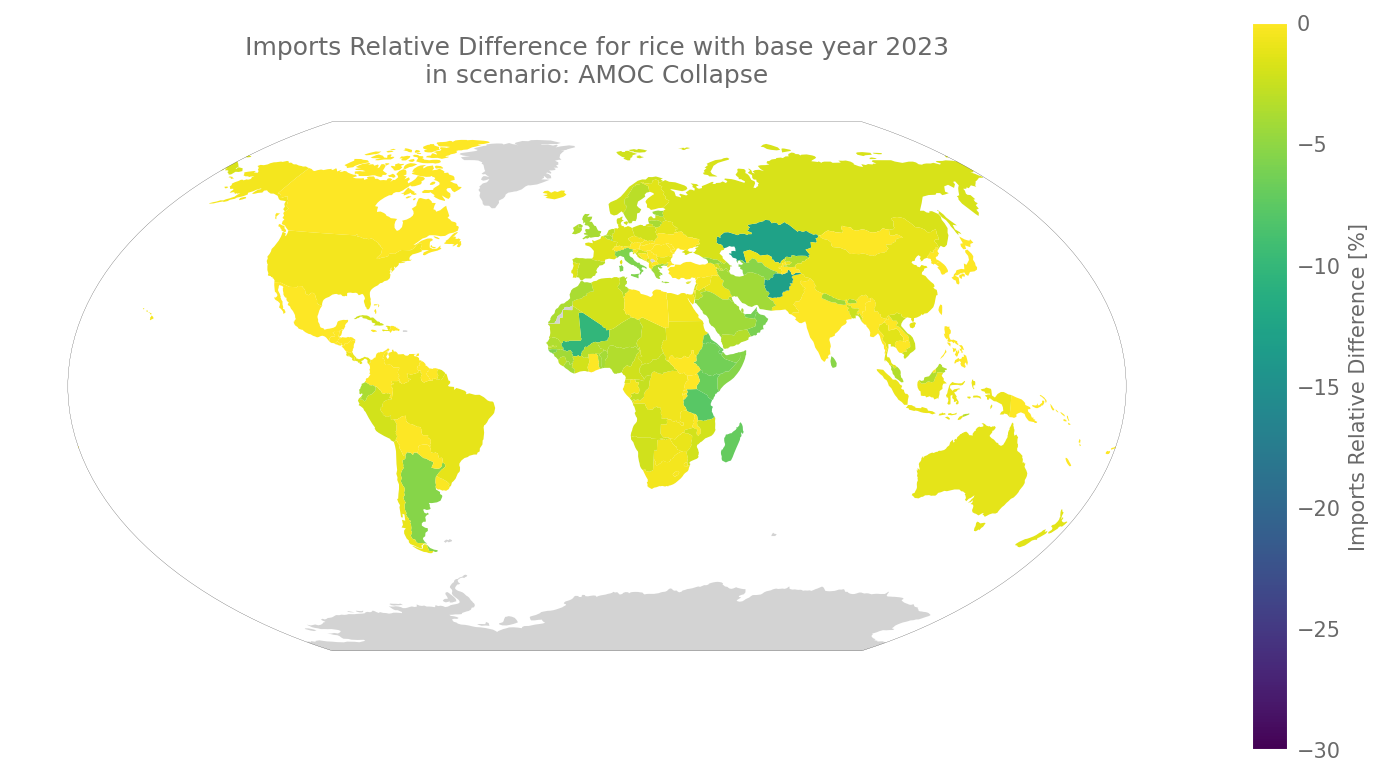

In [16]:
rice_comparison.plot_imports_difference(figsize=(10, 10), vmin=-30, vmax=0, shrink=0.5)

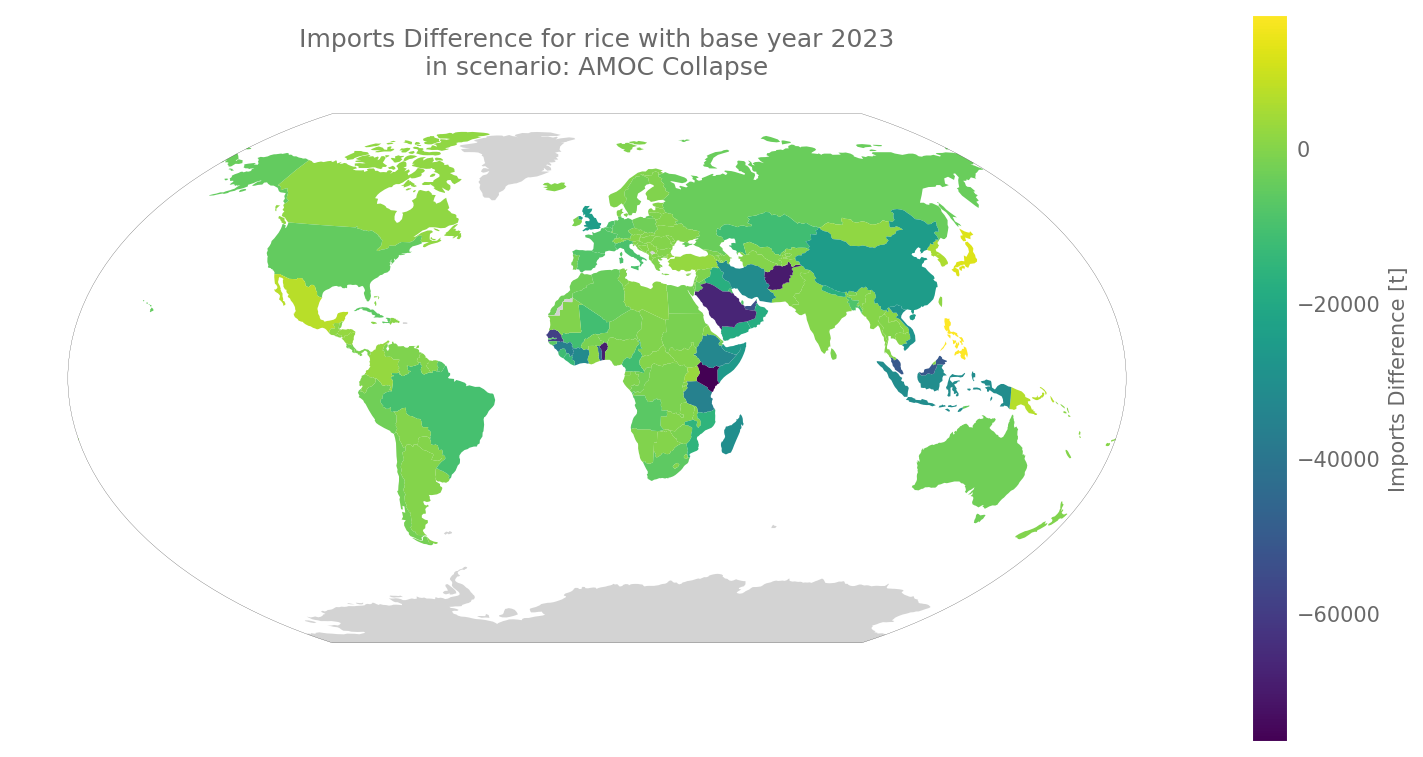

In [17]:
rice_comparison.plot_imports_difference_absolute(figsize=(10, 10), shrink=0.5)

### Import change as fraction of consumption (Rice)

How large is the scenario-induced import change relative to each country's domestic
food consumption of rice? A value of −5 % means a country's imports fell by an amount
equivalent to 5 % of its normal rice consumption.

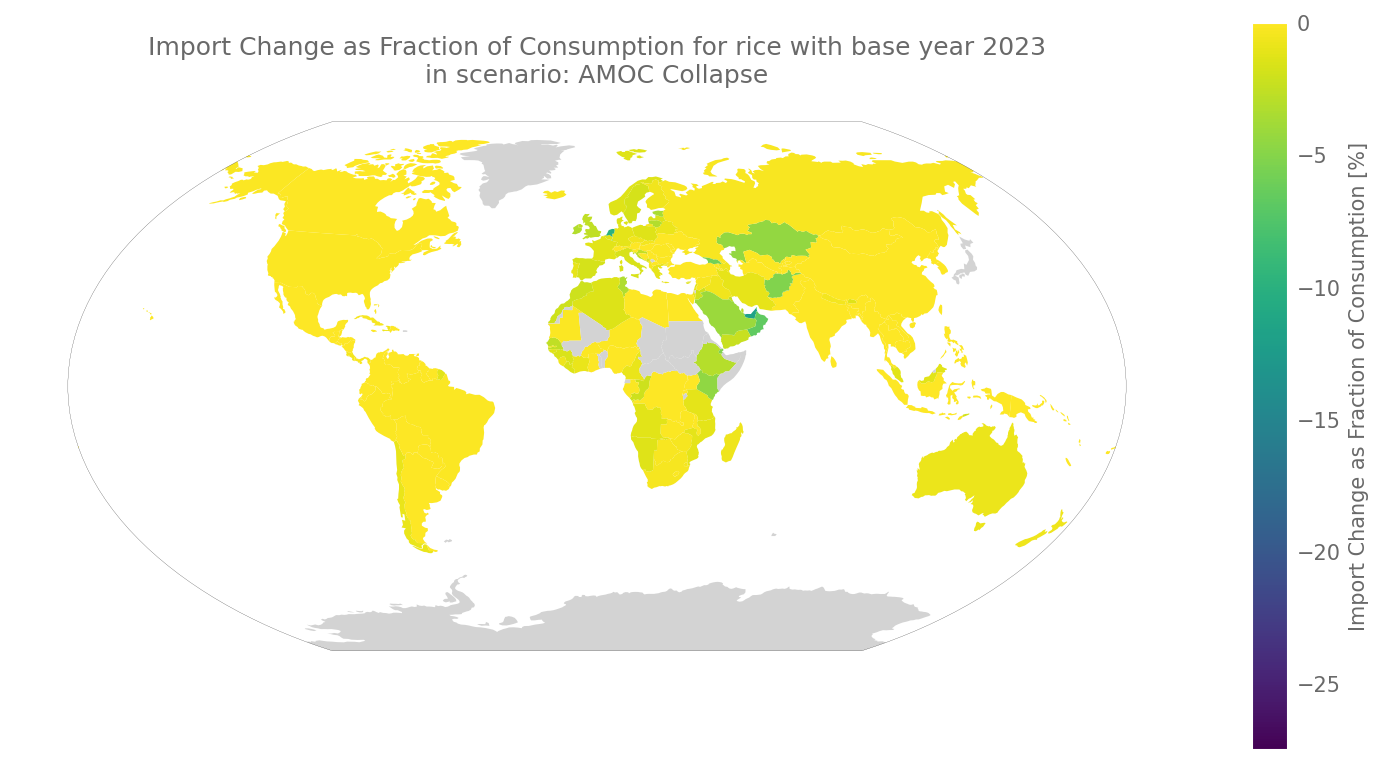

In [24]:
rice_comparison.plot_import_change_as_fraction_of_consumption(figsize=(10, 10), vmax=0, vmin=-27.5, shrink=0.5)

### Trade communities (Rice)

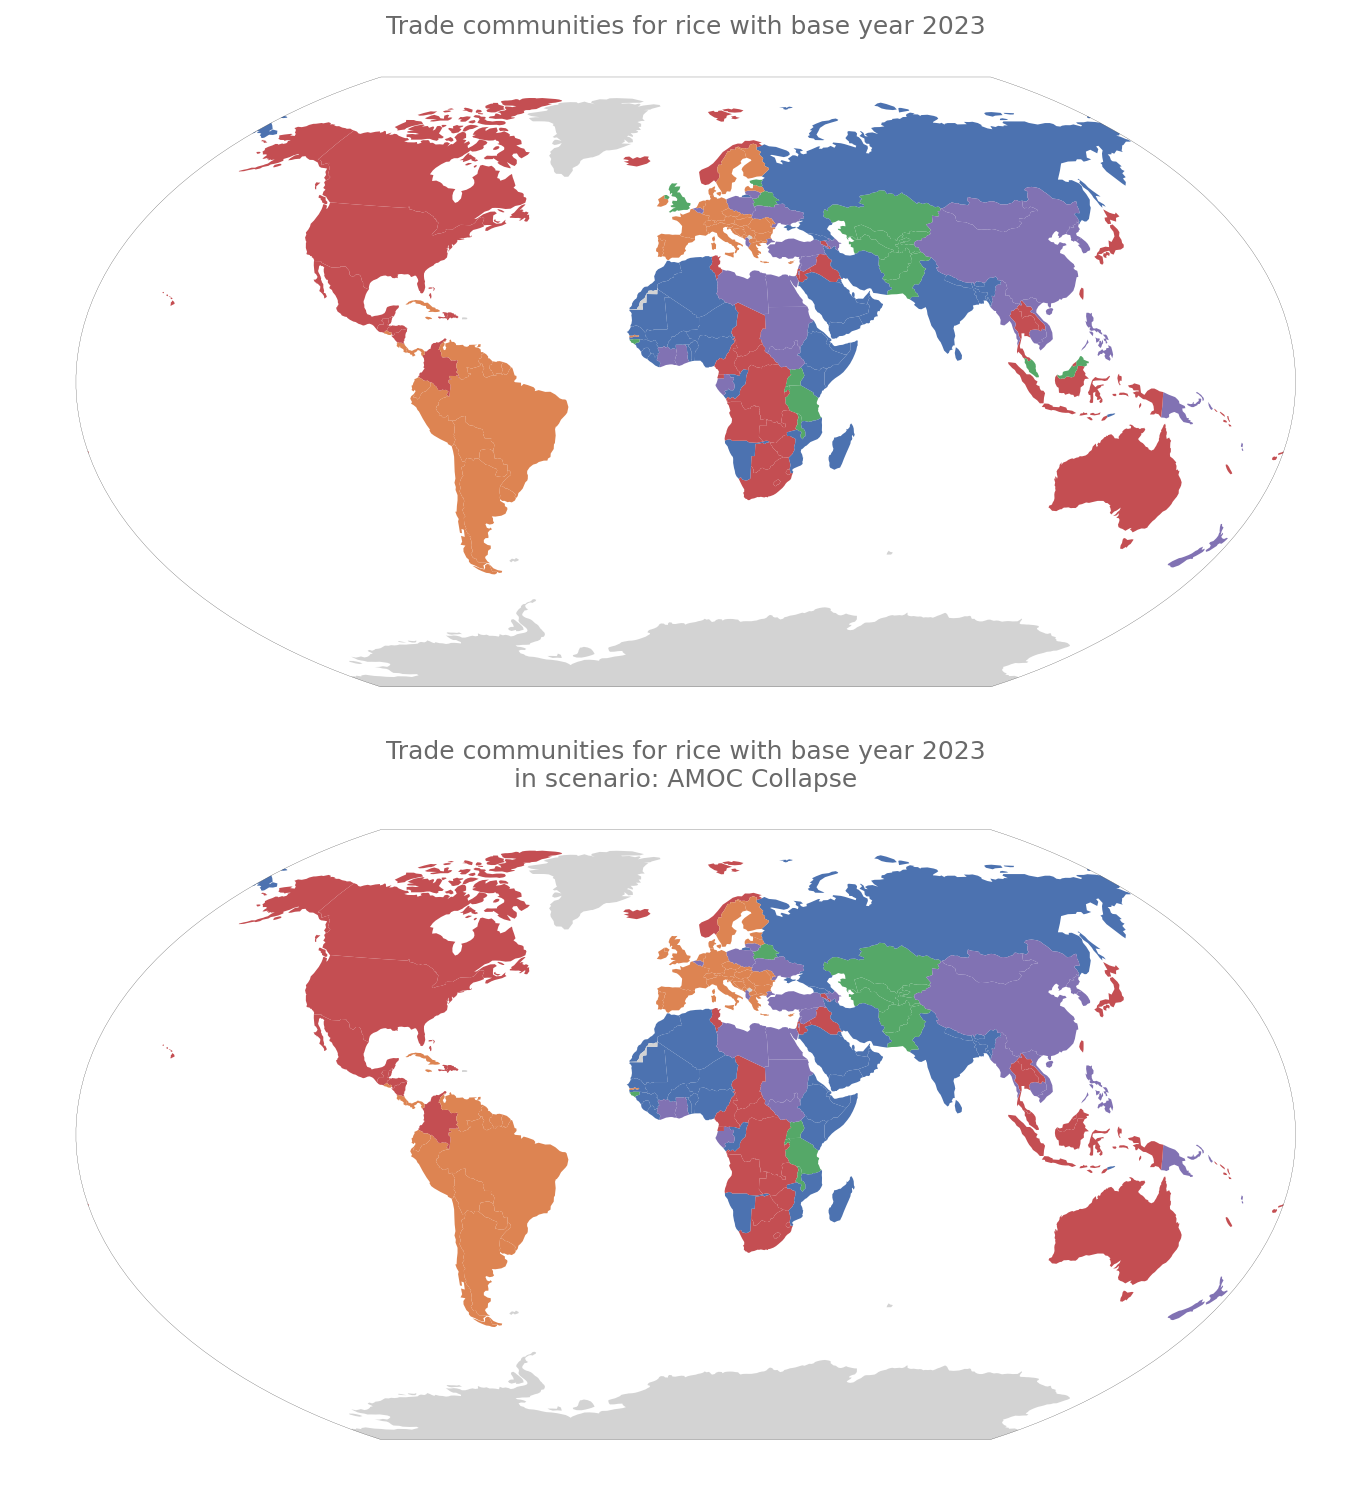

In [19]:
rice_comparison.plot_all_trade_communities(figsize=(15, 10))

### Trade community change — Jaccard distance (Rice)

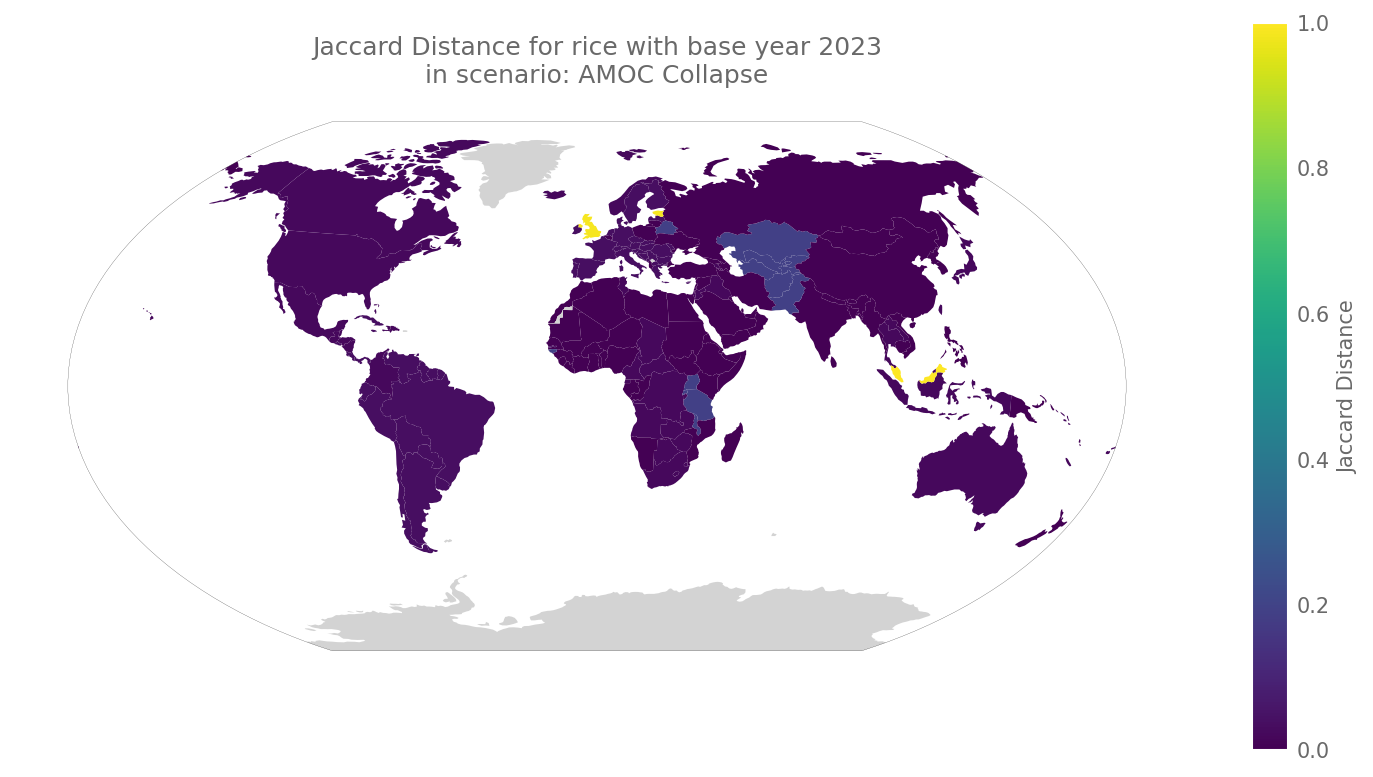

In [20]:
rice_comparison.plot_community_difference(figsize=(10, 10), vmin=0, vmax=1, shrink=0.5)